In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import scipy.stats as sts
import astropy.units as u
from astropy.constants import G,M_sun,kpc
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
import matplotlib.colors as mcol
import matplotlib.cm as mcm
from matplotlib import ticker
import scipy.optimize as sopt
from sim_read import *

plt.style.use('./presentation.mplstyle')

In [2]:
gls = sim(exsub_fields=['SubhaloMass'])
sim.mass_add(gls)

/Users/bhattacharyya.37/TNG50-1/sim_read.py:28: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst, 'group_m200', mconv + np.log10(self.hst.Group_M_Crit200))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:29: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_mst', mconv + np.log10(self.hst.GroupMassType[:,4]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:30: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mgas', mconv + np.log10(self.sub.SubhaloMassInRadType[:,0]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:31: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mst',mconv + np.log10(self.sub.SubhaloMassInRadType[:,4]))


In [3]:
massive_gal,dwarf_gal = dwf_select(gls.sub.mst)
all_gal = np.array([*dwarf_gal,*massive_gal])

sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

1494 10829
1494 10829
-8.346120696830761 -0.17679571397785238


In [4]:
llt,llh,llg,llr,dhost,x200 = sim.field_select(gls,hfloor=9)

N_lll = [len(llh[k]) for k in range(3)]
print(N_lll)
bin_mk = ['o','D','s']
print(N_lll[0]+N_lll[1]+N_lll[2])

1494 10829
12323 0.098584
[5003, 465, 375]
5843


In [5]:
llg_a = np.array([m for i in range(3) for m in llg[i]])
mst_a = np.array([m for i in range(3) for m in gls.sub.mst[llg[i]]])
llt_a = np.array([t for i in range(3) for t in llt[i]])
llh_a = np.array([h for i in range(3) for h in llh[i]])
dhost_a = np.array([d for i in range(3) for d in dhost[i]])
m200_a = gls.hst.group_m200[llh_a]
ssfr_a = np.array([s for i in range(3) for s in gls.sub.ssfr[llg[i]]])
#qnc_a = 1-np.heaviside(ssfr_a-(sfms_intercept -1 + sfms_slope*np.array(mst_a)),1)

#x_a = np.array([x for i in range(3) for x in gls.sub.SubhaloPos[llg[i],0]])*dconv - 25
#y_a = np.array([y for i in range(3) for y in gls.sub.SubhaloPos[llg[i],1]])*dconv - 25
#z_a = np.array([z for i in range(3) for z in gls.sub.SubhaloPos[llg[i],2]])*dconv - 25
#print(len(np.unique(llh_a)))
#print(len(np.unique(llh[1])))

In [6]:
print(len(llg[2]),len(np.unique(llg[2])))

375 363


In [8]:
'''llt,llh,llg,llm,dhost = sim.gal_select(gls)

N_lll = len(llh)

mst_a = np.array([m for i in range(N_lll) for m in gls.sub.mst[llg[i]]])
print(N_lll,len(mst_a),len(np.unique(llh)))
m200_a = np.array([gls.hst.group_m200[llh[i]] for i in range(N_lll) for m in range(llm[i])])

dw_samp = np.where((m200_a<11.5)&(mst_a<9.5))[0]
print(len(m200_a[dw_samp]))'''

'llt,llh,llg,llm,dhost = sim.gal_select(gls)\n\nN_lll = len(llh)\n\nmst_a = np.array([m for i in range(N_lll) for m in gls.sub.mst[llg[i]]])\nprint(N_lll,len(mst_a),len(np.unique(llh)))\nm200_a = np.array([gls.hst.group_m200[llh[i]] for i in range(N_lll) for m in range(llm[i])])\n\ndw_samp = np.where((m200_a<11.5)&(mst_a<9.5))[0]\nprint(len(m200_a[dw_samp]))'

In [7]:
def behroozi(M,M1=11.59,A=-1.459,alpha=-1.972,beta=-0.488,gamma=-0.958,delta=0.391): 
    x = M - M1
    return  M1 + A - np.log10(np.power(10,alpha*x) + np.power(10,beta*x))+np.exp(-0.5*np.square(x/delta)) * 10**gamma

def most(M,M1=11.59,A=2*0.0351,beta=1.376,gamma=0.608): 
    return np.log10(A) + M - np.log10(np.power(10,-beta*(M-M1))+np.power(10,gamma*(M-M1)))

def bradf(M,M1=8.6,A1=1.052,B1=0.236,A2=0.461,B2=5.329):
        MS = most(M)
        return np.concatenate((A1* MS[np.where(MS<M1)[0]] + B1,A2* MS[np.where(MS>=M1)[0]] + B2))

mhalo_bin = np.linspace(10,11.5,50)

0.03357985208874675 0.3273809523809524 0.6726190476190477
0.06881720430107527 0.53125 0.46875
0.8106666666666666 0.9572368421052632 0.04276315789473684


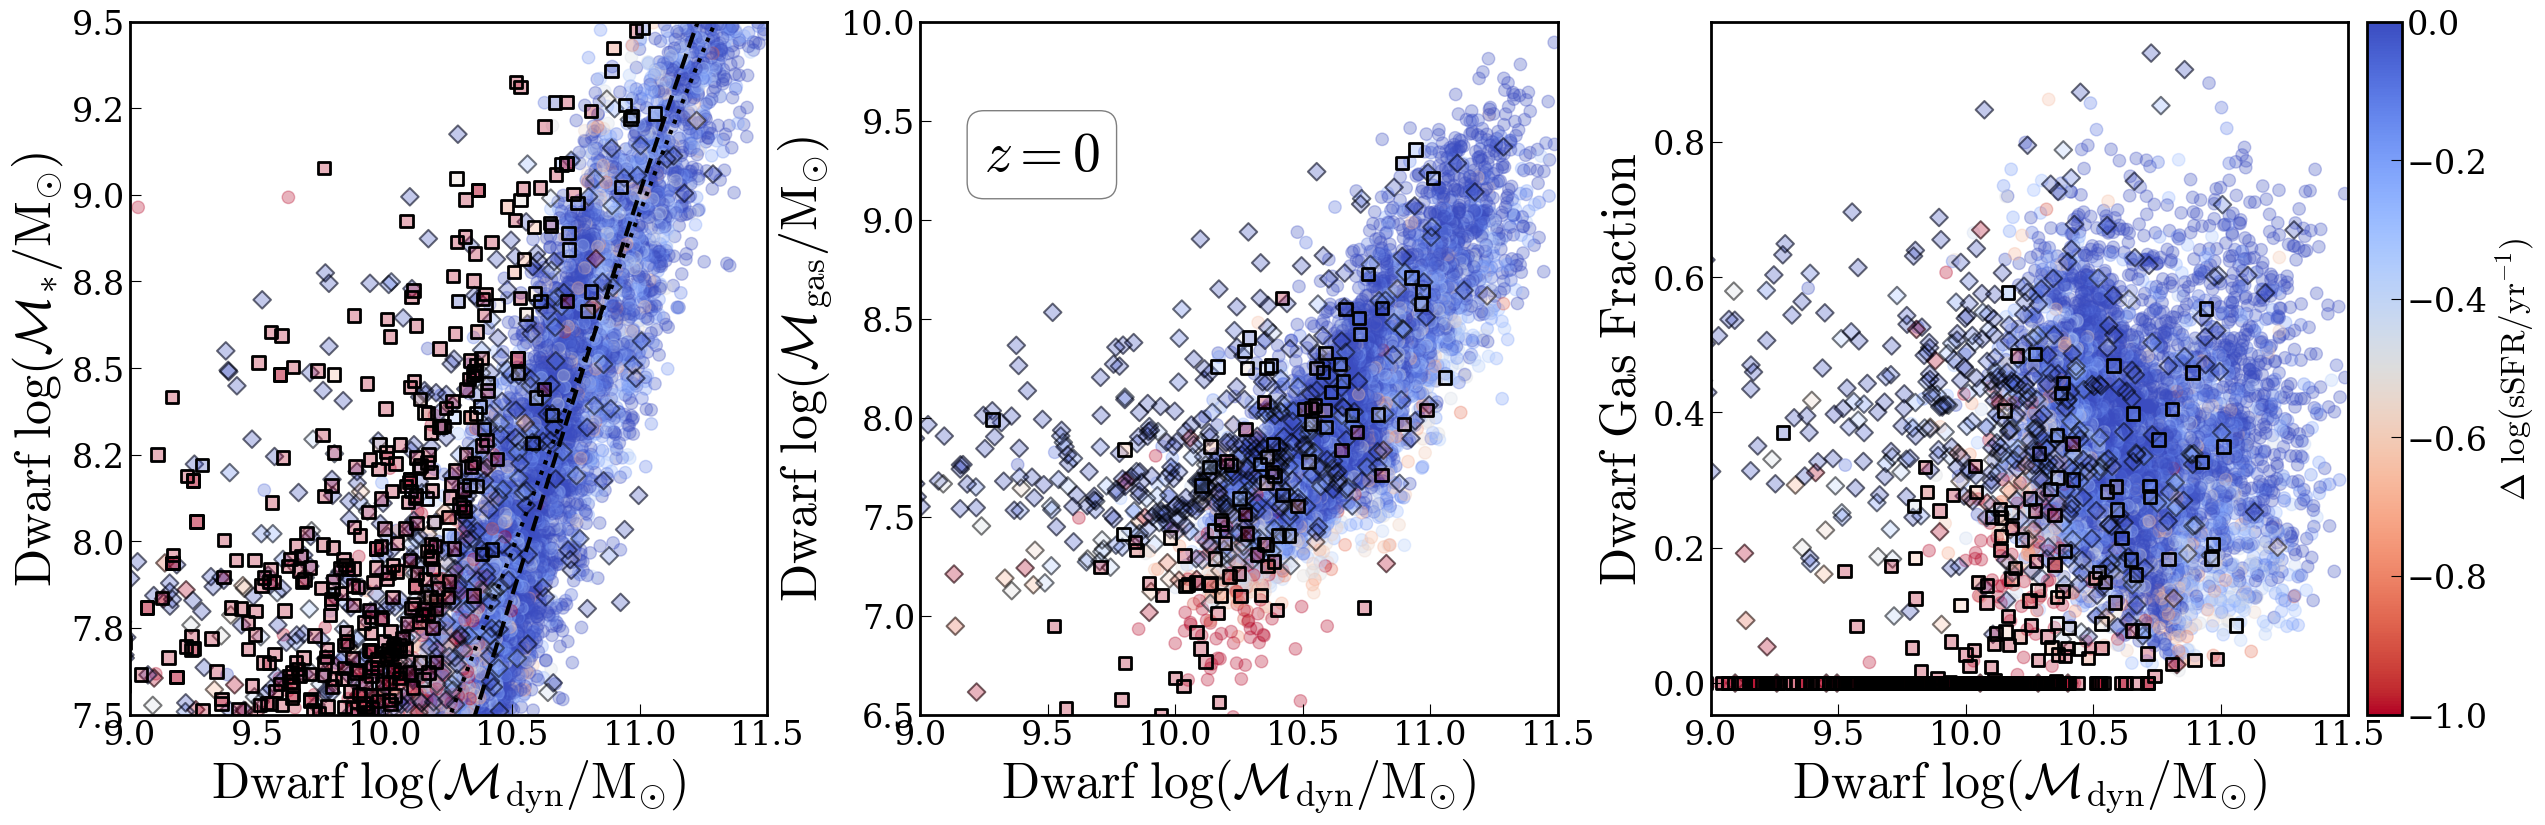

In [9]:
fig,ax=plt.subplots(1,6,figsize=(30,9),sharex=True,width_ratios=[0.32,0.01,0.32,0.01,0.32,0.02])

#dhst_bins = np.linspace(np.log10(0.15),np.log10(15),6)

for k in range(3):
    mst_b = np.array([m for m in gls.sub.mst[llg[k]]])
    mgas_b = np.array([m for m in gls.sub.mgas[llg[k]]])
    #llh_b = np.array([gls.hst.group_m200[h] for h in llh[k]])
    llh_b = 10.155 + np.log10( np.array([gls.sub.SubhaloMass[h] for h in llg[k]]))
    gas_frac = np.power(10,mgas_b)/(np.power(10,mgas_b)+np.power(10,mst_b))

    ssfr_b = np.array([s for s in gls.sub.ssfr[llg[k]]])
    dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))


    print(len(np.where(gas_frac<0.1)[0])/N_lll[k],len(np.where((gas_frac<0.1)&(dsfms_b<-1))[0])/len(np.where(gas_frac<0.1)[0]),len(np.where((gas_frac<0.1)&(dsfms_b>=-1))[0])/len(np.where(gas_frac<0.1)[0]))

    ax[0].scatter(llh_b,mst_b,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80) 
    ax[2].scatter(llh_b,mgas_b,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80) 
    ax[4].scatter(llh_b,gas_frac,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80) 

    if k==1:
        ax[0].scatter(llh_b,mst_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=80)  
        ax[2].scatter(llh_b,mgas_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=80)  
        ax[4].scatter(llh_b,gas_frac,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=80)   


    if k==2:
        ax[0].scatter(llh_b,mst_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=80) 
        ax[2].scatter(llh_b,mgas_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=80) 
        ax[4].scatter(llh_b,gas_frac,c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=80)  

for j in [0,2,4]:
    ax[j].set_xlabel(r'$Dwarf\ log(\mathcal{M}_{dyn}/M_{\odot})$',fontsize=36)
    ax[j].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))


ax[0].set_xlim((9,11.5))
ax[0].set_ylim((7.5,9.5))
ax[2].set_ylim((6.5,10))
ax[5].set_ylim((1e-2,1))
      
ax[0].plot(mhalo_bin,most(mhalo_bin),lw=3,ls='--',color='black')
#ax[2].plot(mhalo_bin,bradf(mhalo_bin),lw=3,ls='--',color='black')
ax[0].plot(mhalo_bin,behroozi(mhalo_bin),lw=3,ls=':',color='black')
ax[5].set_yscale('log')
ax[1].set_axis_off()
ax[3].set_axis_off()
ax[5].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[5], orientation='vertical',fraction=2.2,label=r'$\Delta\ log(sSFR/yr^{-1})$')

ax[2].text(9.25,9.25,r'${\it z=0}$',fontsize=40,bbox=dict(boxstyle='round',facecolor='white', alpha=0.5))
ax[4].set_ylabel(r'$Dwarf\ Gas\ Fraction$',fontsize=36)
ax[2].set_ylabel(r'$Dwarf\ log(\mathcal{M}_{gas}/M_{\odot})$',fontsize=36)
ax[0].set_ylabel(r'$Dwarf\ log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=36)
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))


ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.2)
plt.savefig('group_shmr_count.pdf',bbox_inches='tight')

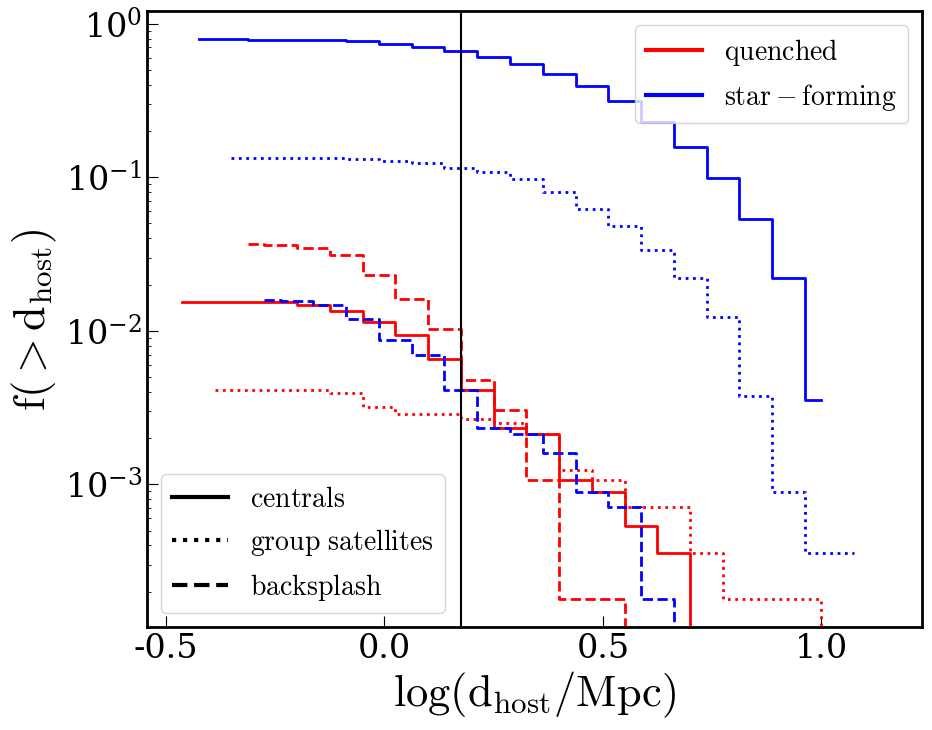

In [39]:
fig,ax=plt.subplots(figsize=(10,8),sharex=True)

dhst_bins = np.linspace(-0.5,1,21)
bin_ls = ['-',':','--']

for k in range(3):
    dhost_b = np.log10(dhost[k])
    qnc_b = gls.sub.ssfr[llg[k]]-(sfms_intercept -1 + sfms_slope*np.array(gls.sub.mst[llg[k]]))
    red = np.where(qnc_b<0)[0]
    blue = np.where(qnc_b>=0)[0]

    bin_sat, bin_edg = np.histogram(dhost_b[red],bins=dhst_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax.step(bin_edg[:-1],np.cumsum(bin_sat[::-1])[::-1]/np.sum(N_lll),color='red',ls=bin_ls[k],lw=2,where='mid')

    bin_sat, bin_edg = np.histogram(dhost_b[blue],bins=dhst_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax.step(bin_edg[:-1],np.cumsum(bin_sat[::-1])[::-1]/np.sum(N_lll),color='blue',ls=bin_ls[k],lw=2,where='mid')

custom_lines = [Line2D([0], [0],lw=3,ls=bin_ls[0], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[1], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[2], color='black')]
leg=Legend(ax,custom_lines,[r'$centrals$',r'$group\ satellites$',r'$backsplash$'],loc='lower left',fontsize=20,framealpha=0.8,frameon=True)
ax.add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax,custom_lines,[r'$quenched$',r'$star-forming$'],loc='upper right',fontsize=20,framealpha=0.8,frameon=True)
ax.add_artist(leg)


ax.axvline(np.log10(1.5),color='black')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))

ax.set_xlabel(r'$log(d_{host}/ Mpc)$',fontsize=32)
ax.set_ylabel(r'$f(>d_{host})$',fontsize=32)
plt.savefig('dwarf_dhost_cumul.pdf',bbox_inches='tight')

In [15]:
print(len(llg[1]))
values, counts = np.unique(llh[1], return_counts=True)
print(len(values))
bin_sec, bin_edg = np.histogram(counts,bins=np.arange(0,6,1))
print(bin_sec)
print(100*bin_sec/len(llg[1]))

505
429
[  0 364  56   7   2]
[ 0.         72.07920792 11.08910891  1.38613861  0.3960396 ]


NameError: name 'host_bins' is not defined

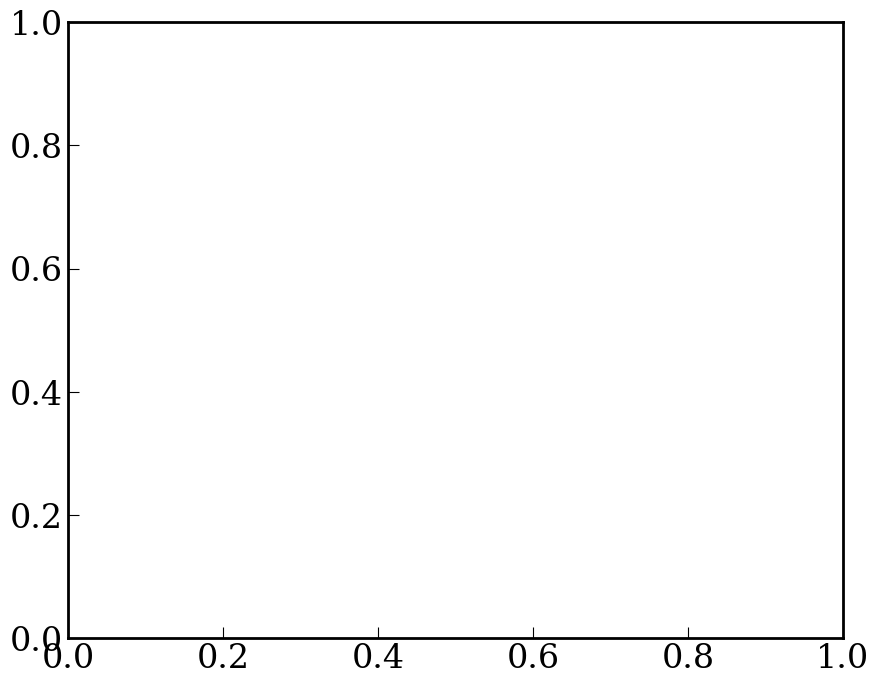

In [7]:
fig,ax=plt.subplots(figsize=(10,8),sharex=True)


for k in range(2):
    llm_b = np.array([llm[i] for i in host_bins[k]])
    print(np.sum(llm_b))
    llg_b = np.array([m for i in host_bins[k] for m in llg[i]])
    dhost_b = np.log10([d for i in host_bins[k] for d in dhost[i]])
    mst_b = np.array([m for i in host_bins[k] for m in gls.sub.mst[llg[i]]])
    #llt_b = np.array([t for i in host_bins[k] for t in llt[i]])
    llh_b = np.array([gls.hst.group_m200[llh[i]] for i in host_bins[k] for m in range(llm[i])])

    ssfr_b = np.array([s for i in host_bins[k] for s in gls.sub.ssfr[llg[i]]])
    dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))

    ax.scatter(llh_b,mst_b,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k]) 

    bklg,llg_int,bkg_int = np.intersect1d(llg_b, back_gal, return_indices=True)

    ax.scatter(llh_b[llg_int],mst_b[llg_int],c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=50) 

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))
   

ax.set_xlabel(r'$log(Host\ \mathcal{M}_{200}/M_{\odot})$',fontsize=32)
ax.set_ylabel(r'$log(Subhalo\ \mathcal{M}_{\ast}/M_{\odot})$',fontsize=32)


ax.set_xlim((10,11.5))
ax.set_ylim((7.5,9.5))
      
fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax, orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$')

ax.set_rasterized(True)
plt.savefig('KITP_shmr_count.pdf',bbox_inches='tight')

In [16]:
host_bins = [np.where((gls.hst.group_m200[llh]<11.0)&(llm>1))[0],np.where((gls.hst.group_m200[llh]>=11.0)&(llm>1))[0]]
bin_cols = ['crimson','royalblue']
bin_ls = ['-','-.',':']

print(len(host_bins[0]),len(host_bins[1]))

isol_bins = [np.where((gls.hst.group_m200[llh]<11.0)&(llm==1))[0],np.where((gls.hst.group_m200[llh]>=11.0)&(llm==1))[0]]
print(len(isol_bins[0]),len(isol_bins[1]))

358 283
6024 428


0.08169306108897743
0.0
[0.04082881 0.08374502 0.23452764 0.10902435 0.06331062]
[-0.04451454  0.00221821  0.16641867  0.0297522  -0.02002992]
[0.44850423 0.21391526 0.12197207 0.05925071 0.03473404]
[ 0.39944013  0.14397763  0.04384961 -0.02445508 -0.05115267]
[0.09410982 0.16592804 0.09589249 0.10073027 0.12438465]
[0.09410982 0.16592804 0.09589249 0.10073027 0.12438465]
[0.28195056 0.15934436 0.04332114 0.         0.00590703]
[0.28195056 0.15934436 0.04332114 0.         0.00590703]


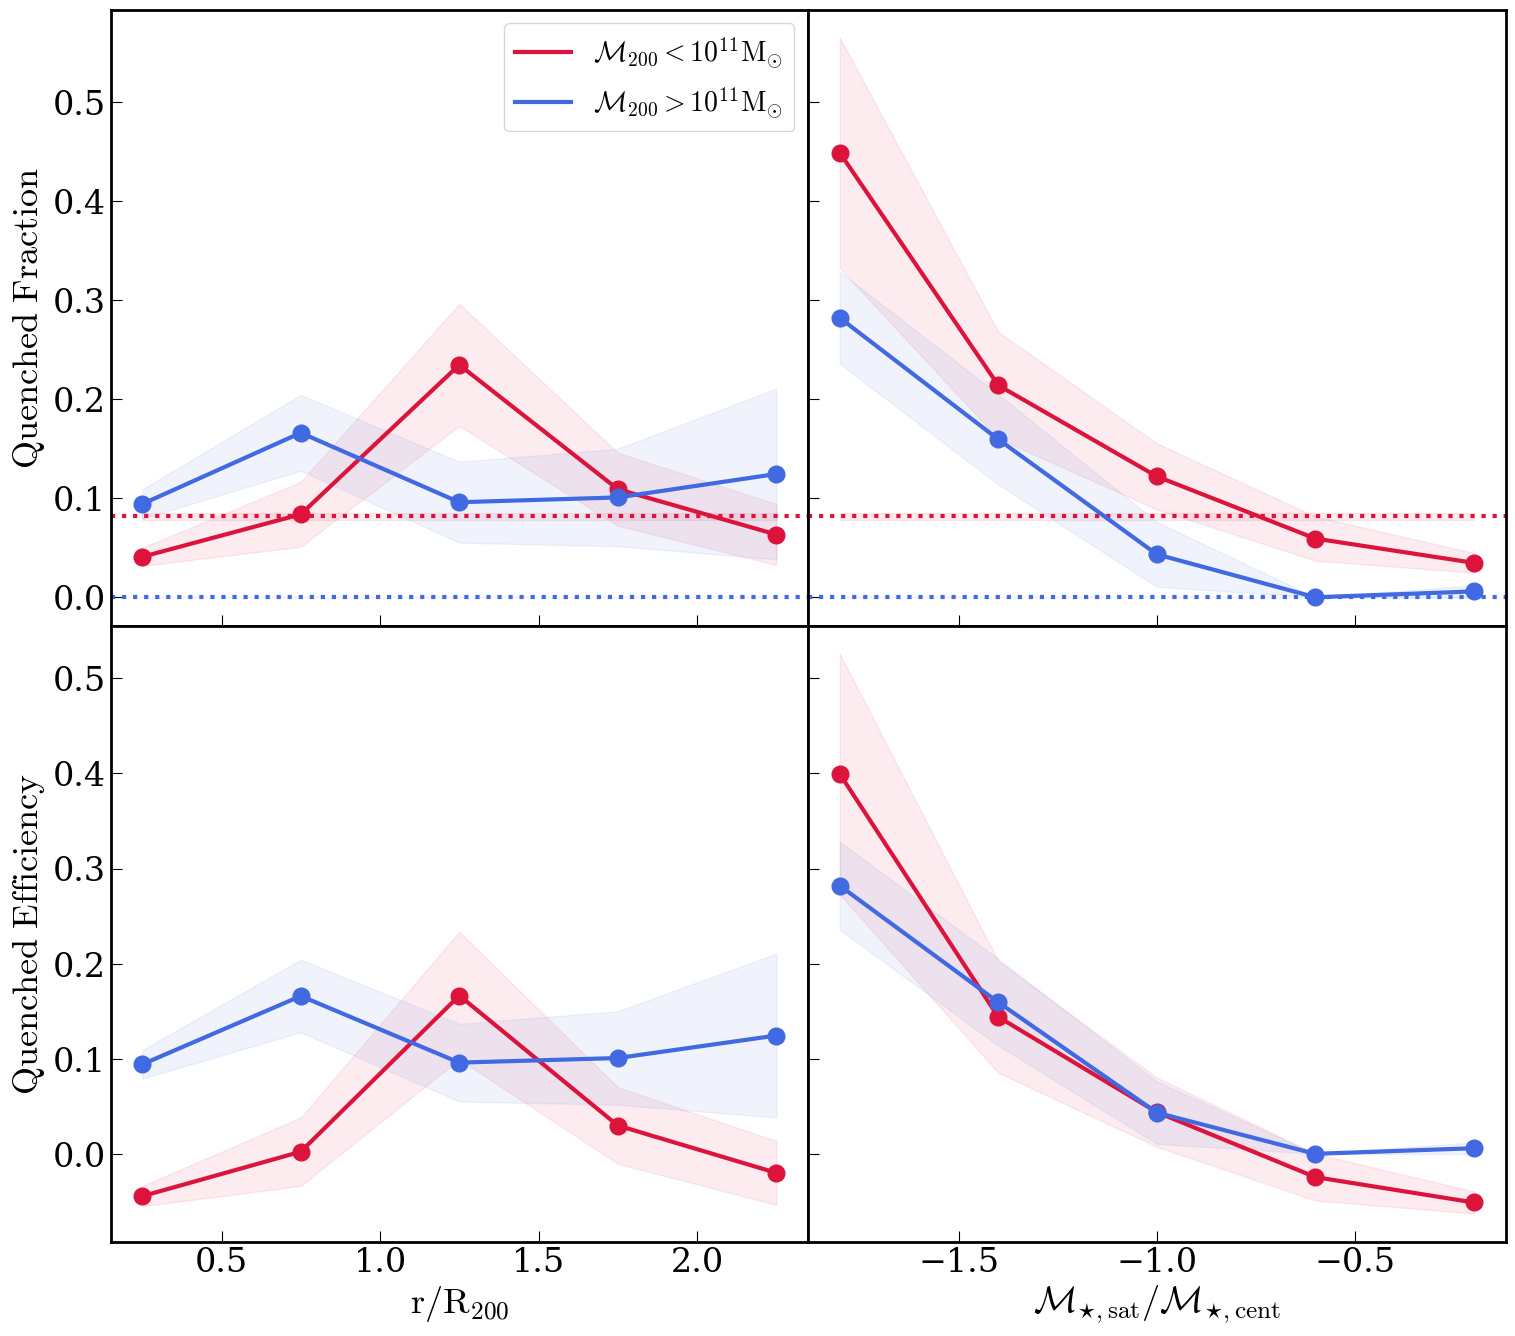

In [69]:
r_bins = np.linspace(0.0,2.5,6)
mst_bins = np.linspace(-2,0,6)
bin_bins = [r_bins+0.5*(r_bins[1]-r_bins[0]),mst_bins+0.5*(mst_bins[1]-mst_bins[0])]

fig,ax=plt.subplots(2,2,figsize=(18,16),sharey='row',sharex='col')

ax[1,0].set_xlabel(r'$r/R_{200}$',fontsize=26)
ax[1,1].set_xlabel(r'$\mathcal{M}_{\star,sat}/\mathcal{M}_{\star,cent}$',fontsize=26)

Nbtsp = 1000
boot_tmp = np.zeros((4,Nbtsp,5))
boot_isol = np.zeros((2,Nbtsp))
boot_qfe = np.zeros((4,Nbtsp,5))

ax[0,0].set_ylabel(r'$Quenched\ Fraction$',fontsize=26)
ax[1,0].set_ylabel(r'$Quenched\ Efficiency$',fontsize=26)

for k in range(2):
    for m in range(Nbtsp):
            boot = npr.choice(isol_bins[k],size=len(isol_bins[k]),replace=True)
            slc = [l for i in boot for l in llg[i]]
    
            isol_red = np.sum(1- np.heaviside(gls.sub.ssfr[slc]-(sfms_intercept -1 + sfms_slope*gls.sub.mst[slc]),1))/len(slc)
            boot_isol[k,m] = isol_red
        
            boot = npr.choice(host_bins[k],size=len(host_bins[k]),replace=True)
    
            grp_r = []
            grp_mst = []
            grp_ssfr = []
            for i in boot: 
                #print(grp_ord)
                r = np.sqrt(np.square(gls.sub.SubhaloPos[llg[i],0]-gls.hst.GroupPos[llh[i],0])+np.square(gls.sub.SubhaloPos[llg[i],1]-gls.hst.GroupPos[llh[i],1])+np.square(gls.sub.SubhaloPos[llg[i],2]-gls.hst.GroupPos[llh[i],2]))
                grp_r.extend(r/gls.hst.Group_R_Crit200[llh[i]])
                grp_mst.extend(gls.sub.mst[llg[i]]-gls.sub.mst[llg[i]][-1])

                ssfr = 1-np.heaviside(gls.sub.ssfr[llg[i]]-(sfms_intercept -1 + sfms_slope*gls.sub.mst[llg[i]]),1)
                grp_ssfr.extend(ssfr)

        
            bin_ssfr, bin_edg, bin_n = sts.binned_statistic(grp_r,grp_ssfr, statistic='mean', bins=r_bins)

            boot_tmp[2*k,m,:] = bin_ssfr
            boot_qfe[2*k,m,:] = (bin_ssfr - isol_red)/(1-isol_red)
    
            bin_ssfr, bin_edg, bin_n = sts.binned_statistic(grp_mst,grp_ssfr, statistic='mean', bins=mst_bins)

            boot_tmp[2*k+1,m,:] = bin_ssfr
            boot_qfe[2*k+1,m,:] = (bin_ssfr - isol_red)/(1-isol_red)

for k in range(2):
        boot_val=np.mean(boot_isol[k,:])
        boot_err=np.std(boot_isol[k,:],ddof=1)

        print(boot_val)

        for j in range(2):
            ax[0,j].axhline(boot_val,lw=3,ls=':',color=bin_cols[k])
            ax[0,j].fill_between(bin_bins[j][:-1],boot_val-boot_err,boot_val+boot_err,color=bin_cols[k],alpha=0.08)

        #ax[k].set_yscale('log')
        #ax[k].set_ylim((0.005,0.5))


for k in range(4):
        boot_val=np.mean(boot_tmp[k,:,:],axis=0)
        boot_err=np.std(boot_tmp[k,:,:],axis=0,ddof=1)

        print(boot_val)
        
        ax[0,k%2].plot(bin_bins[k%2][:-1],boot_val,marker='o',lw=3,color=bin_cols[k//2],markersize=12)
        ax[0,k%2].fill_between(bin_bins[k%2][:-1],boot_val-boot_err,boot_val+boot_err,color=bin_cols[k//2],alpha=0.08)

        boot_val=np.mean(boot_qfe[k,:,:],axis=0)
        boot_err=np.std(boot_qfe[k,:,:],axis=0,ddof=1)

        print(boot_val)
        
        ax[1,k%2].plot(bin_bins[k%2][:-1],boot_val,marker='o',lw=3,color=bin_cols[k//2],markersize=12)
        ax[1,k%2].fill_between(bin_bins[k%2][:-1],boot_val-boot_err,boot_val+boot_err,color=bin_cols[k//2],alpha=0.08)


custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
leg=Legend(ax[0,0],custom_lines,[r'$\mathcal{M}_{200}< 10^{11} M_{\odot}$',r'$\mathcal{M}_{200} >10^{11} M_{\odot}$'],loc='best',fontsize=20,framealpha=0.8,frameon=True)
ax[0,0].add_artist(leg)


plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('group_quench.pdf',bbox_inches='tight')
